In [9]:
# Import essential libraries for authentication
# Spotipy is the go-to Python wrapper for the Spotify API
# Spotify uses OAuth 2.0, so we will import that
import spotipy
from spotipy.oauth2 import SpotifyOAuth
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
import time
import requests
import numpy as np

# Used to hide credentials
from dotenv import load_dotenv
import os

# FastAPI import
from fastapi import APIRouter

In [6]:
# Authentication via spotipy.Spotify()
load_dotenv()
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id=os.getenv("SPOTIFY_CLIENT_ID"),
    client_secret=os.getenv("SPOTIFY_CLIENT_SECRET"),
    redirect_uri=os.getenv("SPOTIFY_REDIRECT_URI"),
    scope="user-library-read user-top-read user-read-recently-played"
))

## Step 1: Pull Listening Data
Fetch liked songs, top tracks (short + medium term), and recently played.

In [7]:
# Pull and store music data from multiple sources
# i.e. Liked Songs, Top Tracks/Artists, and Recently Played"
# Starting with Liked Songs
def get_liked_songs(sp):
    results = sp.current_user_saved_tracks(limit=50)
    tracks = []
    while results:
        for item in results['items']:
            track = item['track']
            if track is None:        # skip any null tracks
                continue
            tracks.append({
                'id': track['id'],
                'name': track['name'],
                'artist': track['artists'][0]['name'],
                'artist_id': track['artists'][0]['id'],
                'popularity': track.get('popularity', 0), # default to 0 if missing
                'source': 'liked'
        })
        results = sp.next(results)  # handles pagination
    return tracks

# Top Tracks
# time_range options:
# - 'short_term'  = last 4 weeks
# - 'medium_term' = last 6 months (default)
# - 'long_term'   = all time
def get_top_tracks(sp, time_range='medium_term', limit=50):
    results = sp.current_user_top_tracks(
        time_range=time_range,
        limit=limit
    )
    tracks = []
    for item in results['items']:
        tracks.append({
            'id': item['id'],
            'name': item['name'],
            'artist': item['artists'][0]['name'],
            'artist_id': item['artists'][0]['id'],
            'popularity': item.get('popularity', 0), # default to 0 if missing
            'source': f'top_tracks_{time_range}'
        })
    return tracks

# Top artists
# Useful for seeding recommendations
# and filtering candidates by genre
def get_top_artists(sp, time_range='medium_term', limit=50):
    results = sp.current_user_top_artists(
        time_range=time_range,
        limit=limit
    )
    artists = []
    for item in results['items']:
        artists.append({
            'id': item['id'],
            'name': item['name'],
            'genres': item.get('genres', []),
            'popularity': item.get('popularity', 0), # default to 0 if missing
            'source': f'top_artists_{time_range}'
        })
    return artists

# Lastly, get recently played
def get_recently_played(sp, limit=50):
    results = sp.current_user_recently_played(limit=limit)
    tracks = []
    for item in results['items']:
        track = item['track']
        if track is None:        # skip any null tracks
                continue
        tracks.append({
            'id': track['id'],
            'name': track['name'],
            'artist': track['artists'][0]['name'],
            'artist_id': track['artists'][0]['id'],
            'played_at': item['played_at'],   # timestamp — useful for weighting
            'source': 'recently_played'
        })
    return tracks

# Combine liked songs, top tracks, and recently played
# To make a cohesive taste profile for the user
def get_full_taste_profile(sp):
    all_tracks = (
        get_liked_songs(sp) +
        get_top_tracks(sp, 'short_term') +
        get_top_tracks(sp, 'medium_term') +
        get_recently_played(sp)
    )
    seen = set()
    unique = []
    for t in all_tracks:
        if t['id'] not in seen:
            seen.add(t['id'])
            unique.append(t)
    return unique

tracks = get_full_taste_profile(sp)
print(f"Total unique tracks in taste profile: {len(tracks)}")

Total unique tracks in taste profile: 933


## Step 2: Last.fm Tag Features
Since Spotify's audio features endpoint is restricted for new apps,
we use Last.fm tags as our feature vectors instead. Last.fm tags
include genre, mood, and style descriptors like 'indie', 'chill',
'melancholic', 'acoustic', etc. — providing richer features than
genre alone.

In [8]:
LASTFM_API_KEY = os.getenv("LASTFM_API_KEY")
LASTFM_BASE_URL = "http://ws.audioscrobbler.com/2.0/"

def get_lastfm_tags(artist, track, max_tags=5):
    try:
        response = requests.get(LASTFM_BASE_URL, params={
            "method": "track.getTopTags",
            "artist": artist,
            "track": track,
            "api_key": LASTFM_API_KEY,
            "format": "json"
        }, timeout=5)
        data = response.json()
        if 'error' in data or 'toptags' not in data:
            return get_lastfm_artist_tags(artist, max_tags)
        tags = [
            t['name'].lower().strip()
            for t in data['toptags']['tag']
            if int(t.get('count', 0)) > 10
        ]
        return tags[:max_tags]
    except Exception as e:
        print(f"Failed for {artist} - {track}: {e}")
        return []

def get_lastfm_artist_tags(artist, max_tags=5):
    try:
        response = requests.get(LASTFM_BASE_URL, params={
            "method": "artist.getTopTags",
            "artist": artist,
            "api_key": LASTFM_API_KEY,
            "format": "json"
        }, timeout=5)
        data = response.json()
        if 'error' in data or 'toptags' not in data:
            return []
        tags = [
            t['name'].lower().strip()
            for t in data['toptags']['tag']
            if int(t.get('count', 0)) > 10
        ]
        return tags[:max_tags]
    except Exception as e:
        print(f"Artist fallback failed for {artist}: {e}")
        return []

def get_lastfm_features(tracks, max_tags=5):
    track_tags = []
    total = len(tracks)
    for i, track in enumerate(tracks):
        tags = get_lastfm_tags(track['artist'], track['name'], max_tags)
        track_tags.append(tags)
        if (i + 1) % 10 == 0:
            print(f"Processed {i + 1}/{total} tracks...")
        time.sleep(0.25)
    filled = sum(1 for t in track_tags if len(t) > 0)
    print(f"\nTracks with tags: {filled}/{total}")
    mlb = MultiLabelBinarizer()
    tag_matrix = mlb.fit_transform(track_tags)
    return tag_matrix, mlb, track_tags

tag_matrix, mlb, track_tags = get_lastfm_features(tracks)
print(f"Tag matrix shape: {tag_matrix.shape}")
print(f"Total unique tags found: {len(mlb.classes_)}")

Processed 10/933 tracks...
Processed 20/933 tracks...
Processed 30/933 tracks...
Processed 40/933 tracks...
Processed 50/933 tracks...
Processed 60/933 tracks...
Processed 70/933 tracks...
Processed 80/933 tracks...
Processed 90/933 tracks...
Processed 100/933 tracks...
Failed for Taylor Swift - Blank Space: HTTPConnectionPool(host='ws.audioscrobbler.com', port=80): Read timed out. (read timeout=5)
Processed 110/933 tracks...
Processed 120/933 tracks...
Processed 130/933 tracks...
Processed 140/933 tracks...
Processed 150/933 tracks...
Processed 160/933 tracks...
Processed 170/933 tracks...
Processed 180/933 tracks...
Processed 190/933 tracks...
Processed 200/933 tracks...
Processed 210/933 tracks...
Processed 220/933 tracks...
Processed 230/933 tracks...
Processed 240/933 tracks...
Processed 250/933 tracks...
Processed 260/933 tracks...
Processed 270/933 tracks...
Processed 280/933 tracks...
Failed for Hxzz - Patience: HTTPConnectionPool(host='ws.audioscrobbler.com', port=80): Read ti

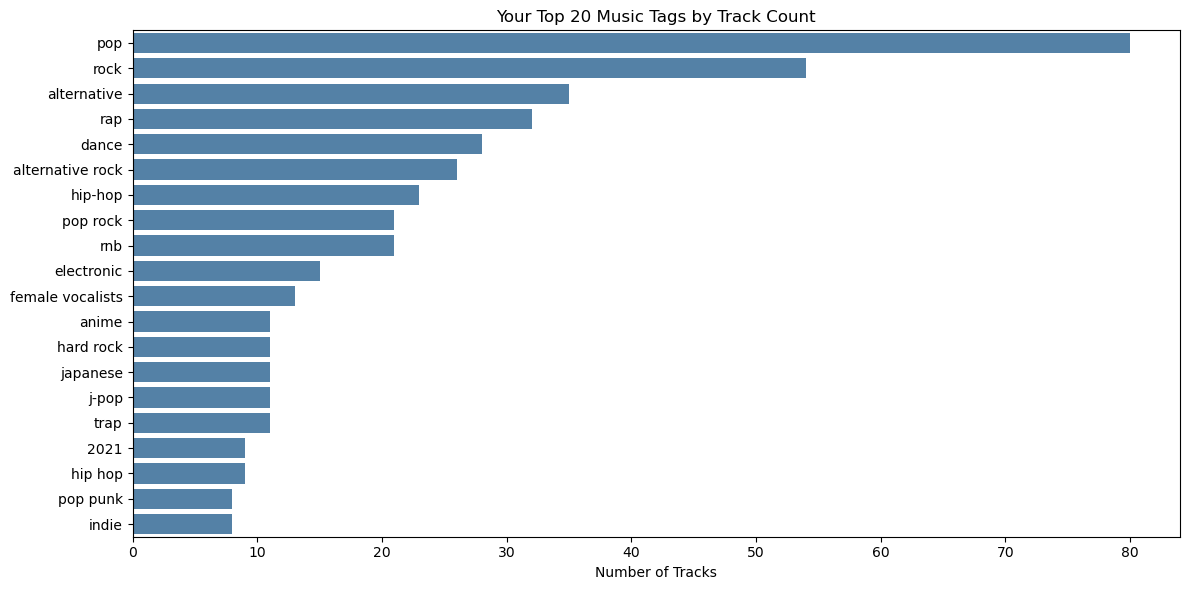

In [11]:
# Visualize feature distribution
# Sum up how many tracks belong to each genre
tag_counts = np.array(tag_matrix.sum(axis=0)).flatten()
tag_names = mlb.classes_

# Get top 20 genres
top_indices = tag_counts.argsort()[::-1][:20]
top_tags = [tag_names[i] for i in top_indices]
top_counts = [tag_counts[i] for i in top_indices]

plt.figure(figsize=(12, 6))
sns.barplot(x=top_counts, y=top_tags, color='steelblue')
plt.title("Your Top 20 Music Tags by Track Count")
plt.xlabel("Number of Tracks")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Step 3: Build User Taste Profile & Score Candidates
Average the audio features of all liked/top/recent tracks to create a single
taste vector, then score Spotify-generated candidates by cosine similarity.

In [3]:
# Recommender model
# Use values from previous functions in order to create model that will recommend songs and artists
def build_recommendations(sp, tracks, features, n=10):
    feature_cols = [
        'danceability', 'energy', 'valence',
        'tempo', 'acousticness', 'instrumentalness', 'loudness'
    ]

    df = pd.DataFrame(features)[feature_cols].dropna()
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df)
    user_profile = scaled.mean(axis=0).reshape(1, -1)

    # get top artists to use as seeds alongside tracks
    top_artists = get_top_artists(sp, limit=50)

    # mix track and artist seeds (max 5 total combined)
    seed_tracks = [t['id'] for t in tracks[:2]]
    seed_artists = [a['id'] for a in top_artists[:3]]

    candidates = sp.recommendations(
        seed_tracks=seed_tracks,
        seed_artists=seed_artists,
        limit=50
    )

    candidate_ids = [t['id'] for t in candidates['tracks']]
    candidate_features = sp.audio_features(candidate_ids)
    candidate_df = pd.DataFrame(
        [f for f in candidate_features if f is not None]
    )[feature_cols].dropna()
    candidate_scaled = scaler.transform(candidate_df)

    similarities = cosine_similarity(user_profile, candidate_scaled)[0]
    top_indices = similarities.argsort()[::-1][:n]

    recommendations = []
    for i in top_indices:
        track = candidates['tracks'][i]
        recommendations.append({
            'name': track['name'],
            'artist': track['artists'][0]['name'],
            'id': track['id'],
            'similarity_score': round(float(similarities[i]), 4)
        })
    return recommendations

In [ ]:
# Visualize similarity scores
rec_df = pd.DataFrame(recommendations)

plt.figure(figsize=(10, 5))
sns.barplot(data=rec_df, x='similarity_score', y='name', color='steelblue')
plt.title("Top 10 Recommended Songs by Similarity Score")
plt.xlabel("Cosine Similarity to Your Taste Profile")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
# API Endpoints
# Want to recommend songs based on the user's full taste profile 
# i.e. Liked Songs + Top Tracks + Recently Played combined
# API will be saved for .py files